# Repeated Syndrome Extraction: Genuine Per-Stabilizer TSVF Post-Selection

## Motivation

The readout-conditioned experiment (the readout-conditioned approach) showed ΔH_true = 0 because
logical-Z is a global parity bit that cannot probe per-stabilizer structure.

This notebook implements an alternative: **two rounds of syndrome extraction**.
Round 1 = forward boundary, Round 2 = backward boundary. Each stabilizer in
Round 2 is a local, temporally distinct post-selection event, giving genuine
per-stabilizer TSVF post-selection without requiring a low-weight Z_L.

## Design

- HaPPY [[5,1,3]] only
- 2 rounds of syndrome extraction (same 4 stabilizers, same ancilla-reuse pattern)
- Data-qubit measurement after Round 2
- 2048 shots x 32 circuits (16 errors x 2 logical states)
- ΔH = H[h|s₁] - H[h|s₁, s₂]

## Key question

Does the per-stabilizer fan-out pattern appear when the backward boundary
is a second syndrome measurement rather than a global parity bit?

In [ ]:
"""Cell 1: Setup"""

!pip install qiskit qiskit-ibm-runtime numpy matplotlib scipy -q

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from functools import reduce
from scipy import stats
import os

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = '.'
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(42)

STABILIZERS = ['XZZXI', 'IXZZX', 'XIXZZ', 'ZXIXZ']
LOGICAL_X = 'XXXXX'
LOGICAL_Z = 'ZZZZZ'

def anticommutes(pa, pb):
    if pa == 'I' or pb == 'I' or pa == pb:
        return False
    return True

def syndrome_of(error):
    syn = []
    for stab in STABILIZERS:
        n_anti = sum(anticommutes(e, s) for e, s in zip(error, stab))
        syn.append(n_anti % 2)
    return tuple(syn)

def pauli_matrix(s):
    I = np.eye(2, dtype=complex)
    X = np.array([[0,1],[1,0]], dtype=complex)
    Y = np.array([[0,-1j],[1j,0]], dtype=complex)
    Z = np.array([[1,0],[0,-1]], dtype=complex)
    mapping = {'I': I, 'X': X, 'Y': Y, 'Z': Z}
    return reduce(np.kron, [mapping[c] for c in s])

def get_logical_state(z_eigenvalue=+1):
    proj = np.eye(32, dtype=complex)
    for g in STABILIZERS:
        proj = proj @ (np.eye(32) + pauli_matrix(g)) / 2
    proj = proj @ (np.eye(32) + z_eigenvalue * pauli_matrix(LOGICAL_Z)) / 2
    eigenvalues, eigenvectors = np.linalg.eigh(proj)
    state = eigenvectors[:, np.argmax(np.real(eigenvalues))]
    return state / np.linalg.norm(state)

ERRORS = ['IIIII']
LABELS = ['I']
for q in range(5):
    for p in 'XYZ':
        e = list('IIIII'); e[q] = p
        ERRORS.append(''.join(e))
        LABELS.append(f'{p}{q}')

SYNDROMES = [syndrome_of(e) for e in ERRORS]

state0 = get_logical_state(+1)
state1 = get_logical_state(-1)

print(f'[[5,1,3]] code: {len(ERRORS)} errors, {len(STABILIZERS)} stabilizers')
print(f'OUTPUT_DIR = {OUTPUT_DIR}')
print('All imports OK')

In [ ]:
"""Cell 2: Configuration"""

IBM_TOKEN = "REDACTED-LEAKED-TOKEN-REVOKED-SET-IBM_QUANTUM_TOKEN-ENV-VAR"
INSTANCE  = "IBM_Fez"
CHANNEL   = "ibm_quantum_platform"

PREFERRED_BACKENDS = ["ibm_fez", "ibm_torino"]

SHOTS = 2048
OPT_LEVEL = 3
USE_SIMULATOR = False

In [ ]:
"""Cell 3: Connect to IBM Quantum"""

service = QiskitRuntimeService(
    channel=CHANNEL,
    token=IBM_TOKEN,
    instance=INSTANCE,
)

if USE_SIMULATOR:
    from qiskit_aer import AerSimulator
    backend = AerSimulator()
    print('Using local simulator')
else:
    available = service.backends(operational=True, simulator=False)
    print(f'Available hardware: {len(available)} backends')

    backend = None
    for name in PREFERRED_BACKENDS:
        if name in [b.name for b in available]:
            backend = service.backend(name)
            break
    if backend is None:
        backend = service.least_busy(operational=True, simulator=False)

    print(f'Selected: {backend.name} ({backend.num_qubits} qubits)')

qiskit_runtime_service._discover_account:WARNING:2026-03-10 08:42:05,121: Loading account with the given token. A saved account will not be used.


Available hardware: 3 backends
Selected: ibm_fez (156 qubits)


In [ ]:
"""Cell 4: Build repeated-syndrome circuits

Two rounds of syndrome extraction on the same ancilla, then data measurement.
Round 1 -> cr_syn1 (4 bits), Round 2 -> cr_syn2 (4 bits), data -> cr_out (5 bits).
"""

def add_syndrome_round(qc, qr, anc, cr_syn):
    for s_idx, stab in enumerate(STABILIZERS):
        qc.reset(anc[0])
        qc.h(anc[0])
        for q_idx, pauli in enumerate(stab):
            if pauli == 'X':
                qc.cx(anc[0], qr[q_idx])
            elif pauli == 'Z':
                qc.cz(anc[0], qr[q_idx])
            elif pauli == 'Y':
                qc.sdg(qr[q_idx])
                qc.cx(anc[0], qr[q_idx])
                qc.s(qr[q_idx])
        qc.h(anc[0])
        qc.measure(anc[0], cr_syn[s_idx])


def build_repeated_circuit(logical_state, error_str):
    state = state0 if logical_state == '0' else state1

    qr  = QuantumRegister(5, 'data')
    anc = QuantumRegister(1, 'anc')
    cr_syn1 = ClassicalRegister(4, 'syn1')
    cr_syn2 = ClassicalRegister(4, 'syn2')
    cr_out  = ClassicalRegister(5, 'out')

    qc = QuantumCircuit(qr, anc, cr_syn1, cr_syn2, cr_out)

    # Prepare logical state
    qc.initialize(state, qr)

    # Inject error
    for q_idx, pauli in enumerate(error_str):
        if pauli == 'X':   qc.x(qr[q_idx])
        elif pauli == 'Y': qc.y(qr[q_idx])
        elif pauli == 'Z': qc.z(qr[q_idx])

    qc.barrier()

    # Round 1: forward boundary
    add_syndrome_round(qc, qr, anc, cr_syn1)

    qc.barrier()

    # Round 2: backward boundary
    add_syndrome_round(qc, qr, anc, cr_syn2)

    qc.barrier()

    # Data measurement
    qc.measure(qr, cr_out)

    return qc


circuits = {}
for state_label in ['0', '1']:
    for err_str, err_label in zip(ERRORS, LABELS):
        key = f'L{state_label}_{err_label}'
        circuits[key] = build_repeated_circuit(state_label, err_str)

print(f'Built {len(circuits)} circuits')
ex = circuits['L0_I']
print(f'Qubits: {ex.num_qubits}, Depth: {ex.depth()}')
print(f'Classical registers: syn1(4) + syn2(4) + out(5) = 13 bits')
print(f'Gates: {dict(ex.count_ops())}')

Built 32 circuits
Qubits: 6, Depth: 66
Classical registers: syn1(4) + syn2(4) + out(5) = 13 bits
Gates: {'h': 16, 'cx': 16, 'cz': 16, 'measure': 13, 'reset': 8, 'barrier': 3, 'initialize': 1}


In [ ]:
"""Cell 5: Transpile and submit"""

circuit_list = list(circuits.values())
circuit_keys = list(circuits.keys())

transpiled = transpile(circuit_list, backend=backend, optimization_level=OPT_LEVEL, seed_transpiler=42)
print(f'Transpiled {len(transpiled)} circuits')
print(f'Example depth (L0_I): {transpiled[0].depth()}')

sampler = Sampler(mode=backend)
job = sampler.run(transpiled, shots=SHOTS)
print(f'Job submitted: {job.job_id()}')

Transpiled 32 circuits
Example depth (L0_I): 251
Job submitted: d6ntisc3pels73a23pa0


In [ ]:
"""Cell 6: Retrieve results and parse bitstrings"""

# If resuming: job = service.job('JOB_ID_HERE')
result = job.result()

hw_data = {}
save_dict = {}

for pub_idx, key in enumerate(circuit_keys):
    pub = result[pub_idx]
    bitarray = pub.data

    # Detect register names (Qiskit may reorder)
    reg_names = sorted(bitarray.__dict__.keys())
    reg_names = [r for r in reg_names if not r.startswith('_')]

    syn1_bits, syn2_bits, out_bits = None, None, None
    for rname in reg_names:
        arr = getattr(bitarray, rname)
        bits = np.array([list(map(int, list(s))) for s in arr.get_bitstrings()])
        if 'syn1' in rname:
            syn1_bits = bits
        elif 'syn2' in rname:
            syn2_bits = bits
        elif 'out' in rname:
            out_bits = bits

    # Fallback: parse by register width if names don't match
    if syn1_bits is None:
        arrays = []
        for rname in reg_names:
            arr = getattr(bitarray, rname)
            arrays.append(np.array([list(map(int, list(s))) for s in arr.get_bitstrings()]))
        widths = [a.shape[1] for a in arrays]
        four_bit = [a for a, w in zip(arrays, widths) if w == 4]
        five_bit = [a for a, w in zip(arrays, widths) if w == 5]
        syn1_bits, syn2_bits = four_bit[0], four_bit[1]
        out_bits = five_bit[0]

    hw_data[key] = {
        'syn1': syn1_bits.astype(int),
        'syn2': syn2_bits.astype(int),
        'out':  out_bits.astype(int),
    }
    save_dict[f'pub{pub_idx}_syn1'] = syn1_bits
    save_dict[f'pub{pub_idx}_syn2'] = syn2_bits
    save_dict[f'pub{pub_idx}_out']  = out_bits

print(f'Parsed {len(hw_data)} circuits, {SHOTS} shots each')
print(f'Example L0_I: syn1 {hw_data["L0_I"]["syn1"].shape}, '
      f'syn2 {hw_data["L0_I"]["syn2"].shape}, out {hw_data["L0_I"]["out"].shape}')

npz_path = os.path.join(OUTPUT_DIR, 'repeated_syndrome_happy.npz')
np.savez(npz_path, **save_dict, keys=circuit_keys)
print(f'Saved: {npz_path}')

In [ ]:
"""Cell 7: ΔH engine — repeated syndrome

Forward:  p_fwd(h|s1)     ∝ P(s1|h) × P_0(h)
DBCI:     p_dbci(h|s1,s2) ∝ P(s1|h) × P_0(h) × P(s2|h)^β

ΔH = H[p_fwd] - H[p_dbci]

Each stabilizer in s2 is a local post-selection event.
"""

def entropy_bits(p):
    p = p[p > 0]
    return -np.sum(p * np.log2(p)) if len(p) > 0 else 0.0

def normalize_logits(logits):
    logits = logits - np.max(logits)
    probs = np.exp(logits)
    Z = np.sum(probs)
    return probs / Z if Z > 1e-300 else np.ones_like(probs) / len(probs)


def compute_delta_H_repeated(hw_data, error_labels, n_hyp=16, n_anc=4,
                              beta=1.0, stab_subset_bwd=None, p_no_err=0.7):
    """ΔH from second syndrome round.

    stab_subset_bwd: which Round-2 stabilizers to include as backward boundary.
        None = all 4. [0] = only S0, etc.
    """
    if stab_subset_bwd is None:
        stab_subset_bwd = list(range(n_anc))

    n_syn1 = 2 ** n_anc
    n_syn2 = 2 ** len(stab_subset_bwd)
    powers1 = 2 ** np.arange(n_anc - 1, -1, -1)
    powers2 = 2 ** np.arange(len(stab_subset_bwd) - 1, -1, -1)

    log_p0 = np.zeros(n_hyp)
    log_p0[0] = np.log(max(p_no_err, 1e-10))
    log_p0[1:] = np.log(max((1 - p_no_err) / (n_hyp - 1), 1e-10))

    all_dH = []
    all_correct_fwd = []
    all_correct_dbci = []

    for state in ['0', '1']:
        state_syn1, state_syn2 = {}, {}
        for h, lbl in enumerate(error_labels):
            key = f'L{state}_{lbl}'
            if key in hw_data:
                state_syn1[h] = hw_data[key]['syn1']
                state_syn2[h] = hw_data[key]['syn2'][:, stab_subset_bwd]

        if not state_syn1:
            continue

        n_shots = len(next(iter(state_syn1.values())))
        mid = n_shots // 2

        for test_sl, train_sl in [(slice(0, mid), slice(mid, None)),
                                   (slice(mid, None), slice(0, mid))]:

            # P(s1|h) from training half
            logP_s1 = np.full((n_hyp, n_syn1), -np.log(n_syn1))
            # P(s2_sub|h) from training half
            logP_s2 = np.full((n_hyp, n_syn2), -np.log(n_syn2))

            for h in state_syn1:
                s1_train = (state_syn1[h][train_sl] * powers1).sum(axis=1).astype(int)
                s2_train = (state_syn2[h][train_sl] * powers2).sum(axis=1).astype(int)

                cnt1 = np.bincount(s1_train, minlength=n_syn1).astype(float) + 1
                logP_s1[h] = np.log(cnt1 / cnt1.sum())

                cnt2 = np.bincount(s2_train, minlength=n_syn2).astype(float) + 1
                logP_s2[h] = np.log(cnt2 / cnt2.sum())

            # Evaluate on held-out shots
            for h_true in state_syn1:
                s1_test = (state_syn1[h_true][test_sl] * powers1).sum(axis=1).astype(int)
                s2_test = (state_syn2[h_true][test_sl] * powers2).sum(axis=1).astype(int)

                for s1k, s2k in zip(s1_test, s2_test):
                    logf = log_p0 + logP_s1[:, s1k]
                    pfwd = normalize_logits(logf)

                    logd = logf + beta * logP_s2[:, s2k]
                    pdbci = normalize_logits(logd)

                    all_dH.append(entropy_bits(pfwd) - entropy_bits(pdbci))
                    all_correct_fwd.append(int(np.argmax(pfwd) == h_true))
                    all_correct_dbci.append(int(np.argmax(pdbci) == h_true))

    all_dH = np.array(all_dH)
    return (np.mean(all_dH), np.std(all_dH) / np.sqrt(len(all_dH)),
            np.mean(all_correct_fwd), np.mean(all_correct_dbci), all_dH)

print('Repeated-syndrome ΔH engine defined.')

Repeated-syndrome ΔH engine defined.


In [ ]:
"""Cell 8: Global ΔH — all 4 stabilizers as backward boundary"""

dH, sem, acc_f, acc_d, raw = compute_delta_H_repeated(hw_data, LABELS)

print(f'Global ΔH (all 4 Round-2 stabilizers as backward boundary):')
print(f'  ΔH = {dH:.4f} ± {sem:.4f} bits')
print(f'  Accuracy: forward {acc_f*100:.1f}%, DBCI {acc_d*100:.1f}%, Δ = {(acc_d-acc_f)*100:+.1f}pp')
print(f'\nCompare: readout-conditioned ΔH was 0.0004 (zero)')
print(f'Compare: prior-based ΔH was 3.44 at β=20')

Global ΔH (all 4 Round-2 stabilizers as backward boundary):
  ΔH = -0.0062 ± 0.0006 bits
  Accuracy: forward 6.2%, DBCI 6.2%, Δ = +0.0pp

Compare: readout-conditioned ΔH was 0.0004 (zero)
Compare: prior-based ΔH was 3.44 at β=20


In [ ]:
"""Cell 9: Per-stabilizer ΔH — each Round-2 stabilizer as individual backward boundary

The critical test: does the fan-out pattern appear when each backward
boundary event is a single, local stabilizer measurement?
"""

print('Per-stabilizer ΔH (each Round-2 stabilizer individually):')
print(f'{"Stab":<6} {"Operator":<8} {"ΔH":>8} {"± SEM":>8} {"Acc_fwd":>8} {"Acc_dbci":>9}')
print('-' * 50)

per_stab_dH = []
for si in range(4):
    dH, sem, acc_f, acc_d, _ = compute_delta_H_repeated(
        hw_data, LABELS, stab_subset_bwd=[si])
    per_stab_dH.append(dH)
    print(f'S{si:<5} {STABILIZERS[si]:<8} {dH:8.4f} {sem:8.4f} {acc_f*100:7.1f}% {acc_d*100:8.1f}%')

spread = max(per_stab_dH) - min(per_stab_dH)
cv = np.std(per_stab_dH) / abs(np.mean(per_stab_dH)) * 100 if abs(np.mean(per_stab_dH)) > 1e-10 else 0
print(f'\nSpread: {spread:.4f} bits')
print(f'CV: {cv:.1f}%')
print(f'\nCompare: prior-based per-stabilizer spread was 0.205 bits (fan-out)')
print(f'Compare: readout-conditioned spread was 0.0004 bits (zero)')

Per-stabilizer ΔH (each Round-2 stabilizer individually):
Stab   Operator       ΔH    ± SEM  Acc_fwd  Acc_dbci
--------------------------------------------------
S0     XZZXI     -0.0004   0.0002     6.2%      6.2%
S1     IXZZX     -0.0004   0.0001     6.2%      6.2%
S2     XIXZZ     -0.0020   0.0003     6.2%      6.2%
S3     ZXIXZ     -0.0010   0.0003     6.2%      6.2%

Spread: 0.0016 bits
CV: 69.8%

Compare: prior-based per-stabilizer spread was 0.205 bits (fan-out)
Compare: readout-conditioned spread was 0.0004 bits (zero)


Global ΔH vs β (Round-2 strength sweep):
  β=  0.0: ΔH = 0.0000 ± 0.0000
  β=  0.1: ΔH = -0.0006 ± 0.0001
  β=  0.2: ΔH = -0.0014 ± 0.0002
  β=  0.5: ΔH = -0.0029 ± 0.0003
  β=  0.8: ΔH = -0.0045 ± 0.0005
  β=  1.0: ΔH = -0.0062 ± 0.0006
  β=  1.5: ΔH = -0.0095 ± 0.0009
  β=  2.0: ΔH = -0.0126 ± 0.0012
  β=  5.0: ΔH = 0.0071 ± 0.0026
  β= 10.0: ΔH = 0.3543 ± 0.0039
  β= 20.0: ΔH = 1.2754 ± 0.0038


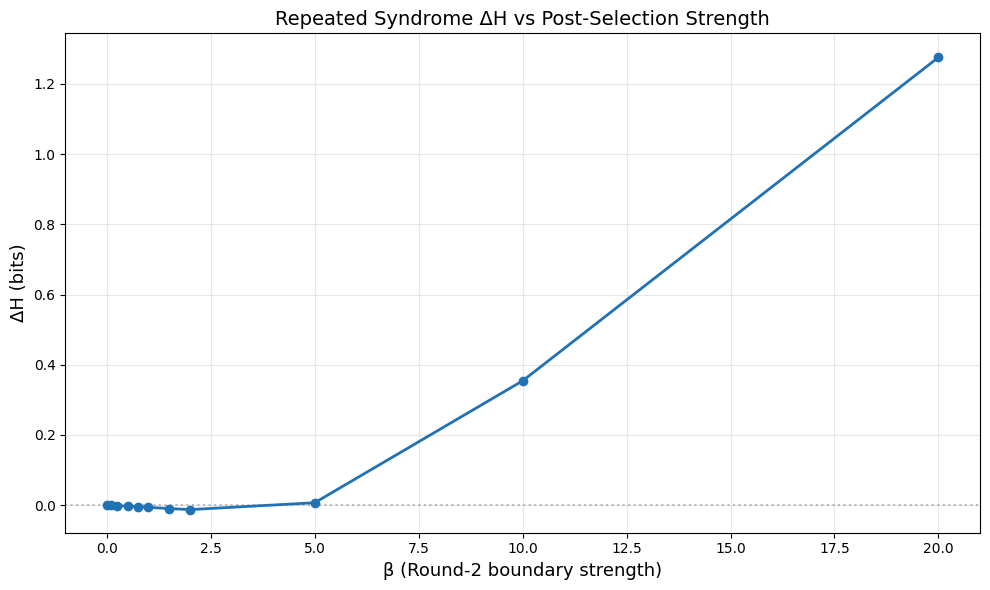

In [ ]:
"""Cell 10: β sweep — repeated syndrome strength"""

beta_values = np.array([0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 5.0, 10.0, 20.0])

print('Global ΔH vs β (Round-2 strength sweep):')
sweep_means, sweep_sems = [], []
for b in beta_values:
    dH, sem, _, _, _ = compute_delta_H_repeated(hw_data, LABELS, beta=b)
    sweep_means.append(dH)
    sweep_sems.append(sem)
    print(f'  β={b:5.1f}: ΔH = {dH:.4f} ± {sem:.4f}')

sweep_means = np.array(sweep_means)
sweep_sems = np.array(sweep_sems)

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(beta_values, sweep_means, yerr=sweep_sems, fmt='o-', lw=2, ms=6, color='#2171b5')
ax.set_xlabel('β (Round-2 boundary strength)', fontsize=13)
ax.set_ylabel('ΔH (bits)', fontsize=13)
ax.set_title('Repeated Syndrome ΔH vs Post-Selection Strength', fontsize=14)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', ls=':', alpha=0.5)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'repeated_syndrome_beta_sweep.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

Per-stabilizer ΔH vs β:
  S0 XZZXI: range [-0.0033, 0.0170]
  S1 IXZZX: range [-0.0194, 0.0000]
  S2 XIXZZ: range [-0.0189, 0.0821]
  S3 ZXIXZ: range [-0.0010, 0.0454]


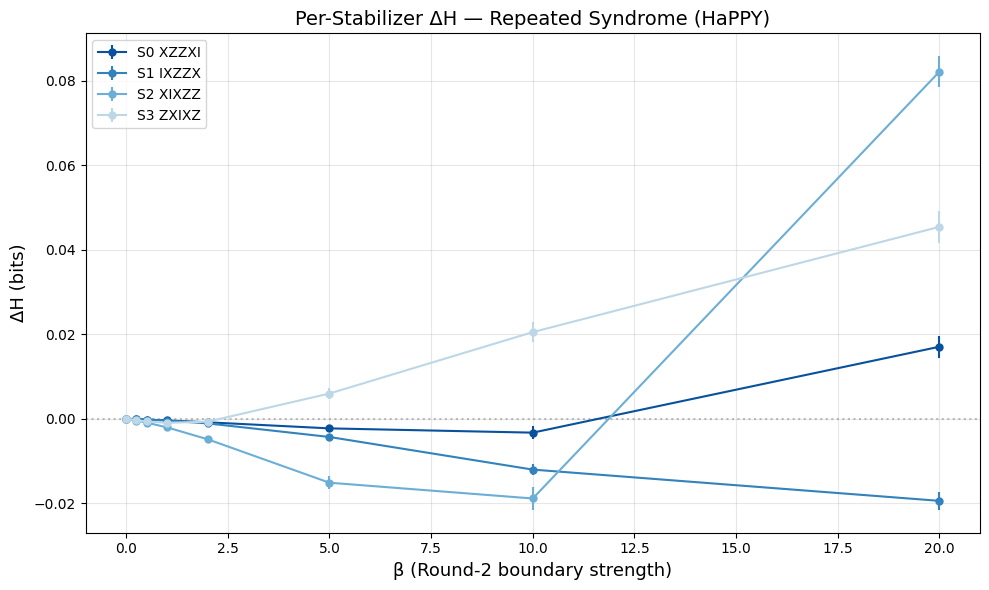

In [ ]:
"""Cell 11: Per-stabilizer β sweep — fan-out test"""

beta_per_stab = np.array([0, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0])

print('Per-stabilizer ΔH vs β:')
per_stab_sweep = {}
for si in range(4):
    means, sems = [], []
    for b in beta_per_stab:
        dH, sem, _, _, _ = compute_delta_H_repeated(
            hw_data, LABELS, beta=b, stab_subset_bwd=[si])
        means.append(dH)
        sems.append(sem)
    per_stab_sweep[si] = (np.array(means), np.array(sems))
    print(f'  S{si} {STABILIZERS[si]}: range [{min(means):.4f}, {max(means):.4f}]')

# Fan-out plot
fig, ax = plt.subplots(figsize=(10, 6))
colors_stab = ['#08519c', '#3182bd', '#6baed6', '#bdd7e7']
for si in range(4):
    mv, sv = per_stab_sweep[si]
    ax.errorbar(beta_per_stab, mv, yerr=sv, fmt='o-', lw=1.5, ms=5,
                label=f'S{si} {STABILIZERS[si]}', color=colors_stab[si])
ax.set_xlabel('β (Round-2 boundary strength)', fontsize=13)
ax.set_ylabel('ΔH (bits)', fontsize=13)
ax.set_title('Per-Stabilizer ΔH — Repeated Syndrome (HaPPY)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', ls=':', alpha=0.5)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'repeated_syndrome_per_stab_sweep.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

# Spread at saturation
sat_vals = [per_stab_sweep[si][0][-1] for si in range(4)]
spread = max(sat_vals) - min(sat_vals)
print(f'\nSpread at β=20: {spread:.4f} bits')
print(f'Compare: prior-based spread = 0.205 bits')
print(f'Compare: readout-conditioned spread = 0.0004 bits')

In [ ]:
"""Cell 12: Syndrome agreement — Round 1 vs Round 2

If Round 2 reproduces Round 1 faithfully, agreement should be high for
no-error circuits and error-dependent for others. This validates that
both rounds are extracting meaningful stabilizer information.
"""

print('Syndrome agreement (Round 1 == Round 2):')
print(f'{"Circuit":<12} {"Agreement":>10} {"S0":>6} {"S1":>6} {"S2":>6} {"S3":>6}')
print('-' * 48)

for key in ['L0_I', 'L0_X0', 'L0_Z0', 'L0_Y0', 'L1_I']:
    if key not in hw_data:
        continue
    s1 = hw_data[key]['syn1']
    s2 = hw_data[key]['syn2']
    full_agree = np.all(s1 == s2, axis=1).mean()
    per_stab = [(s1[:, i] == s2[:, i]).mean() for i in range(4)]
    print(f'{key:<12} {full_agree*100:9.1f}% {per_stab[0]*100:5.1f}% '
          f'{per_stab[1]*100:5.1f}% {per_stab[2]*100:5.1f}% {per_stab[3]*100:5.1f}%')

Syndrome agreement (Round 1 == Round 2):
Circuit       Agreement     S0     S1     S2     S3
------------------------------------------------
L0_I              11.3%  53.3%  52.4%  55.2%  56.3%
L0_X0             10.4%  54.3%  54.5%  53.6%  56.6%
L0_Z0             11.0%  52.5%  57.4%  54.3%  57.5%
L0_Y0              9.6%  52.0%  54.6%  55.0%  55.5%
L1_I              12.5%  55.0%  54.3%  58.9%  56.2%


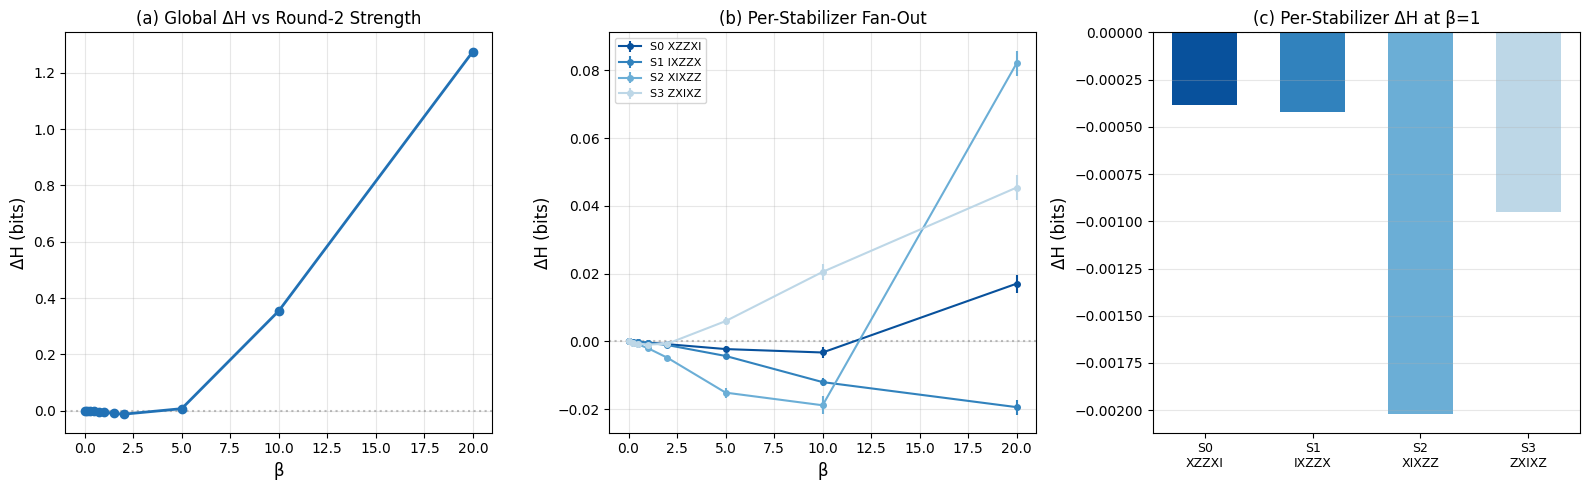

In [ ]:
"""Cell 13: Publication figure — 3-panel"""

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Global β sweep
ax = axes[0]
ax.errorbar(beta_values, sweep_means, yerr=sweep_sems, fmt='o-', lw=2, ms=6, color='#2171b5')
ax.set_xlabel('β', fontsize=12)
ax.set_ylabel('ΔH (bits)', fontsize=12)
ax.set_title('(a) Global ΔH vs Round-2 Strength', fontsize=12)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', ls=':', alpha=0.5)

# (b) Per-stabilizer β sweep
ax = axes[1]
for si in range(4):
    mv, sv = per_stab_sweep[si]
    ax.errorbar(beta_per_stab, mv, yerr=sv, fmt='o-', lw=1.5, ms=4,
                label=f'S{si} {STABILIZERS[si]}', color=colors_stab[si])
ax.set_xlabel('β', fontsize=12)
ax.set_ylabel('ΔH (bits)', fontsize=12)
ax.set_title('(b) Per-Stabilizer Fan-Out', fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', ls=':', alpha=0.5)

# (c) Per-stabilizer at β=1
ax = axes[2]
x = np.arange(4)
ax.bar(x, per_stab_dH, color=colors_stab, width=0.6)
ax.set_xticks(x)
ax.set_xticklabels([f'S{i}\n{STABILIZERS[i]}' for i in range(4)], fontsize=9)
ax.set_ylabel('ΔH (bits)', fontsize=12)
ax.set_title('(c) Per-Stabilizer ΔH at β=1', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='gray', ls=':', alpha=0.5)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'repeated_syndrome_3panel.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

In [ ]:
"""Cell 14: Save all results"""

# Recompute global values to avoid variable shadowing from sweep cells
dH_global, sem_global, acc_f_global, acc_d_global, _ = compute_delta_H_repeated(hw_data, LABELS)

save_all = {
    'global_dH': dH_global,
    'global_sem': sem_global,
    'global_acc_fwd': acc_f_global,
    'global_acc_dbci': acc_d_global,
    'per_stab_dH': np.array(per_stab_dH),
    'beta_sweep': beta_values,
    'sweep_means': sweep_means,
    'sweep_sems': sweep_sems,
    'beta_per_stab': beta_per_stab,
}
for si in range(4):
    save_all[f'stab{si}_sweep_means'] = per_stab_sweep[si][0]
    save_all[f'stab{si}_sweep_sems'] = per_stab_sweep[si][1]

npz_path = os.path.join(OUTPUT_DIR, 'repeated_syndrome_results.npz')
np.savez(npz_path, **save_all)
print(f'Results saved: {npz_path}')

# Summary
print('\n' + '=' * 70)
print('REPEATED SYNDROME EXTRACTION — SUMMARY')
print('=' * 70)
print(f'\nGlobal ΔH (β=1): {dH_global:.4f} ± {sem_global:.4f} bits')
print(f'Accuracy lift: {(acc_d_global-acc_f_global)*100:+.1f}pp')
print(f'\nPer-stabilizer ΔH at β=1:')
for si in range(4):
    print(f'  S{si} {STABILIZERS[si]}: {per_stab_dH[si]:.4f}')
spread = max(per_stab_dH) - min(per_stab_dH)
print(f'  Spread: {spread:.4f} bits')
print(f'\nThree backward boundaries compared:')
print(f'  Prior (calibration):       ΔH = 3.44, spread = 0.205 (fan-out)')
print(f'  Readout (Cohen, Z_L):      ΔH ≈ 0,   spread ≈ 0     (null)')
print(f'  Repeated syndrome (TSVF):  ΔH = {dH_global:.4f}, spread = {spread:.4f}')
print('=' * 70)